In [461]:
import torch
from torch.distributions import Dirichlet, Categorical, Normal
import matplotlib.pyplot as plt
import matplotlib as mpl
import mpltern
import numpy as np
import pandas as pd

# Create synthetic classification dataset

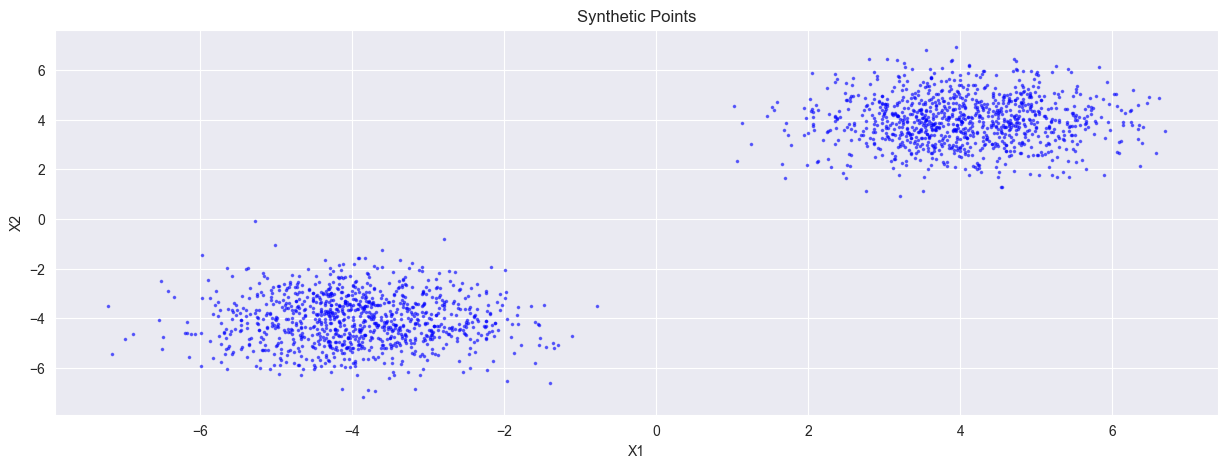

In [462]:
def generate_x_points(n_samples=1000,bias=1):
    """
    Generate n_samples points in the simplex.
    """
    # Generate random points in the simplex
    x1_corr = Normal(0, 1).sample((n_samples,))
    x2_corr = Normal(0, 1).sample((n_samples,))
    points = torch.stack([x1_corr, x2_corr], dim=1).numpy() + bias
    return points

# visualize the points
def visualize_points(points):
    """
    Visualize the points in the simplex.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    ax.scatter(points[:,0], points[:,1], marker='.', s=10, alpha=0.5, color='blue')
    ax.set_title("Synthetic Points")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.show()

# Generate points
point_bunch = generate_x_points(bias=-4)
point_buncH2 = generate_x_points(bias=4)
points = np.concatenate((point_bunch,point_buncH2),axis=0)
# Visualize points
visualize_points(points)

# Define True Target Probability Distribution

In [463]:
# define 1st order probability distribution

def generate_y_probs(points):
    probs = 1 / (1+ torch.exp(
        -points.sum(dim=1)
    ))
    y_probs = torch.stack([1-probs, probs], dim=-1)
    return y_probs.clip(1e-8,(9999999)/1e7)

def generate_target_and_probs(points):
    y_probs = generate_y_probs(points)
    y_labels = torch.argmax(y_probs, dim=1)
    return y_labels, y_probs

y_labels, y_probs = generate_target_and_probs(torch.tensor(points))
y_probs

tensor([[9.9780e-01, 2.2037e-03],
        [9.9889e-01, 1.1056e-03],
        [9.9953e-01, 4.6519e-04],
        ...,
        [8.7839e-04, 9.9912e-01],
        [6.2156e-04, 9.9938e-01],
        [4.5812e-04, 9.9954e-01]])

# Define Ensemble

In [464]:
ENSEMBLE_MEMBER_COUNT = 10


# define (mimic) ensemble
def noisy_probability(points,generator):
    y_probs = generate_y_probs(points)
    noise = 5*torch.randn(y_probs.size(),
                        generator=generator,
                        dtype=y_probs.dtype,
                        layout=y_probs.layout,
                        device=y_probs.device)
    y_probs_noisy = torch.logit(y_probs).add(noise).softmax(dim=-1)
    return y_probs_noisy
def ensemble_probs(points):
    y_probs_ensemble = torch.stack([noisy_probability(points,
                                                      torch.Generator().manual_seed(i)
                                                      ) for i in range(ENSEMBLE_MEMBER_COUNT)])
    return y_probs_ensemble

def ensemble_preditions(points):
    y_probs_ensemble = ensemble_probs(points)
    return y_probs_ensemble.mean(dim=0).argmax(dim=1)
y_probs_ensemble_points = ensemble_probs(torch.tensor(points))
y_pred_ensemble_points = ensemble_preditions(torch.tensor(points))
y_pred_ensemble_points
ensemble_probs(torch.tensor([[10,10]]))

tensor([[[1.1474e-11, 1.0000e+00]],

        [[8.5664e-15, 1.0000e+00]],

        [[2.5920e-14, 1.0000e+00]],

        [[2.7603e-14, 1.0000e+00]],

        [[1.2180e-19, 1.0000e+00]],

        [[2.1402e-15, 1.0000e+00]],

        [[1.4582e-17, 1.0000e+00]],

        [[1.1232e-17, 1.0000e+00]],

        [[2.6884e-12, 1.0000e+00]],

        [[1.0549e-19, 1.0000e+00]]])

In [465]:
def total_uncertainty_ensemble(y_probs_ensemble):
    y_probs_mean = y_probs_ensemble.mean(dim=0)
    return y_probs_mean.mul(y_probs_mean.log2()).sum(dim=-1).mul(-1)

def aleatoric_uncertainty_ensemble(y_probs_ensemble):
    return y_probs_ensemble.mul(y_probs_ensemble.log2()).sum(dim=-1).mul(-1).mean(dim=0)

def epistemic_uncertainty_ensemble(y_probs_ensemble):
    return (total_uncertainty_ensemble(y_probs_ensemble) - aleatoric_uncertainty_ensemble(y_probs_ensemble)).clip(0,1)


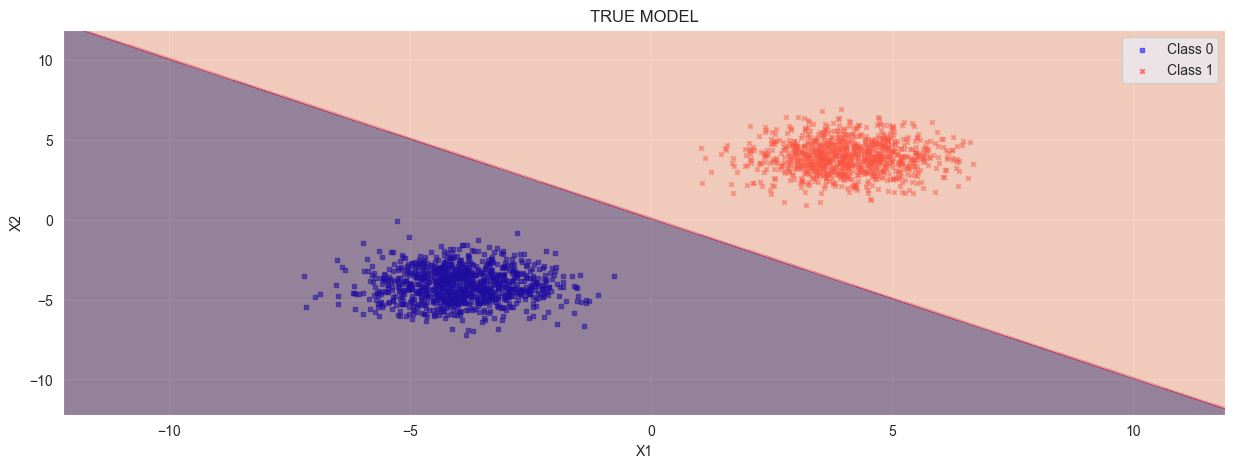

In [466]:
# visualize the labels distribution for the points
def visualize_labels_distribution(points,y_labels):
     # Create gird of points
    grid_points = np.linspace(points.min()-5, points.max()+5, 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    grid_y_labels,_ = generate_target_and_probs(torch.tensor(grid_points))
    gird_y_labels = grid_y_labels.numpy()

    # Plot the points
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # Plot TU
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.contourf(xx, yy, grid_y_labels.reshape(xx.shape),levels=2, alpha=0.5)
    ax.set_title("TRUE MODEL")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    plt.legend()
    plt.show()

visualize_labels_distribution(points,y_labels)

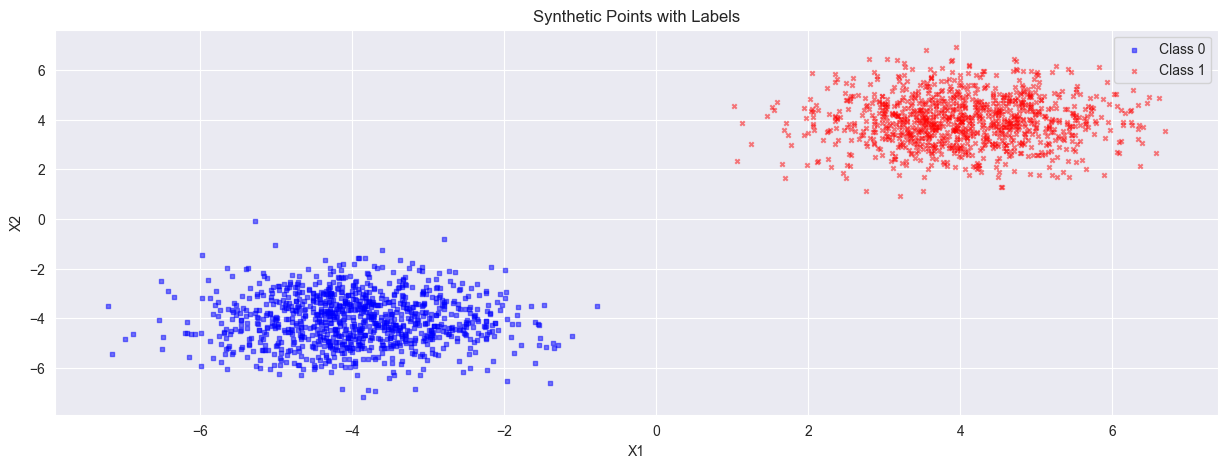

In [467]:
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points with Labels")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()

# Visualize points and labels
visualize_points_and_labels(points, y_labels)

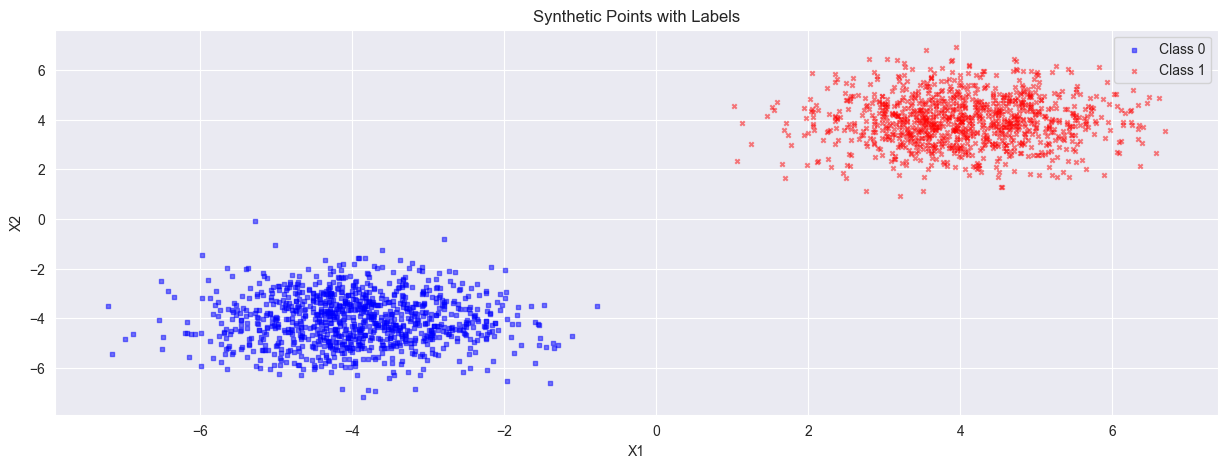

In [468]:
# visualize predictions of the ensemble
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points with Labels")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()


# Visualize points and labels
visualize_points_and_labels(points, y_pred_ensemble_points)


tensor(0.) tensor(1.)


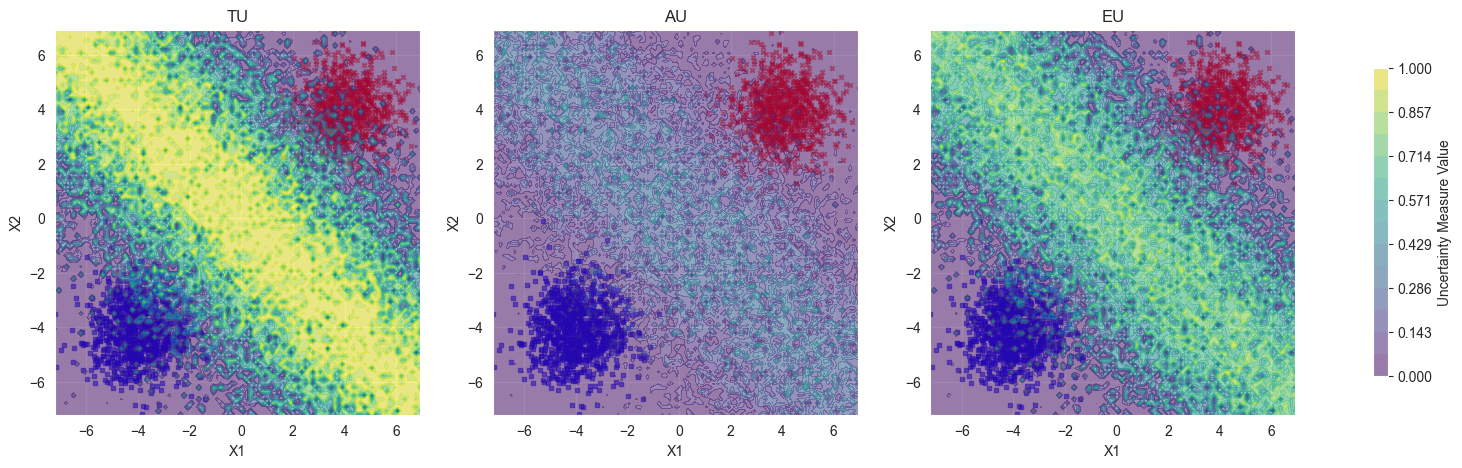

In [469]:
# Look at a given point and AU,EU,TU
def visualize_au_eu_tu_points(points,y_labels):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    y_probs_ensemble = ensemble_probs(torch.tensor(grid_points))
    total_uncertainty = total_uncertainty_ensemble(y_probs_ensemble)
    aleatoric_uncertainty = aleatoric_uncertainty_ensemble(y_probs_ensemble)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(y_probs_ensemble)

    # Shared value range
    all_vals = torch.concatenate([total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

    plots = []
    for ax, data, title in zip(axes, [total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], ["TU", "AU", "EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_au_eu_tu_points(points,y_pred_ensemble_points)

# CF construction

In [470]:
MAX_STEPS = 1000
UNCERTAINTY_STEP_INCREASE = 0.1
DESIRED_VALIDITY = 0.9

### Validity
We now work in the scenario of creating a valid counter factual for our point x

In [471]:
point_of_interest = torch.tensor(np.array([-4,-4]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([0]))
desired_class = 1

In [472]:
def validity_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    # Get the probs in the start
    probs = ensemble_probs(counter_factual).mean(dim=0)
    target_probs = probs[0,desired_class]
    # Optimization Iteration
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs = ensemble_probs(counter_factual).mean(dim=0)
        target_probs = probs[0,desired_class]
        # Calculate the loss
        loss = -target_probs

        # Backpropagate
        loss.backward()
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))

        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_valid, cf_steps_valid = validity_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

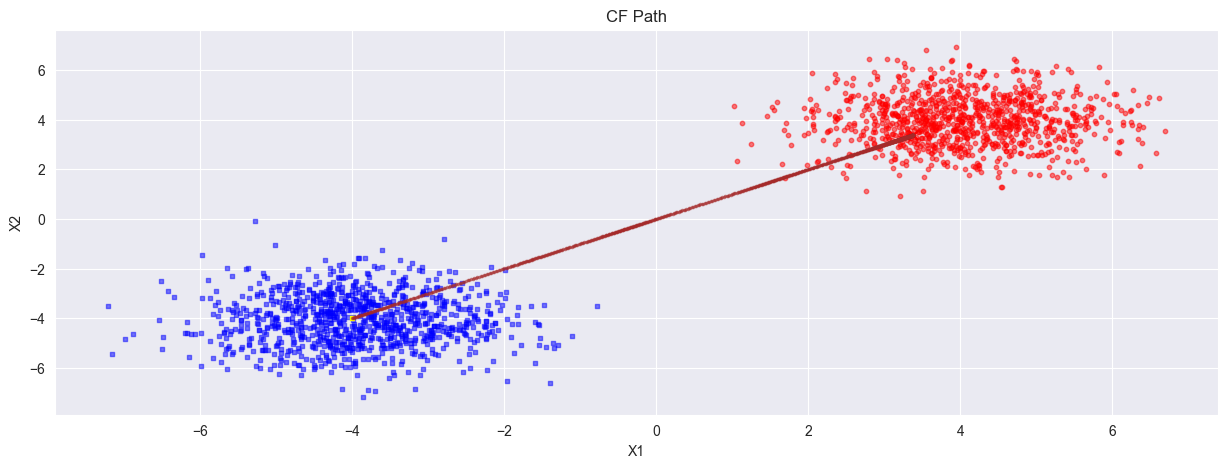

In [473]:
def visualize_cf_and_steps(cf,cf_steps, points, y_labels):
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # visualize the data itself
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='o', s=10, alpha=0.5, color='red', label='Class 1')

    ax.scatter(point_of_interest[:,0].detach(), point_of_interest[:,1].detach(), marker='s', s=10, alpha=1, color='yellow')

    ax.scatter(cf[:,0], cf[:,1], marker='x', s=50, alpha=1, color='red')

    ax.scatter(cf_steps[:,0], cf_steps[:,1], marker='.', s=10, alpha=0.5, color='brown')
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_title("CF Path")
visualize_cf_and_steps(cf_valid, cf_steps_valid, points, y_labels)

## Plausability

In [474]:
point_of_interest = torch.tensor(np.array([-4,-4]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([0]))
desired_class = 1

In [475]:
def plausability_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration
    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)


        target_probs = probs[0,desired_class]
        # Calculate the loss
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        loss = (-target_probs).add(t*eu)

        # Backpropagate
        loss.backward()
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_plausable, cf_steps_plausable = plausability_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

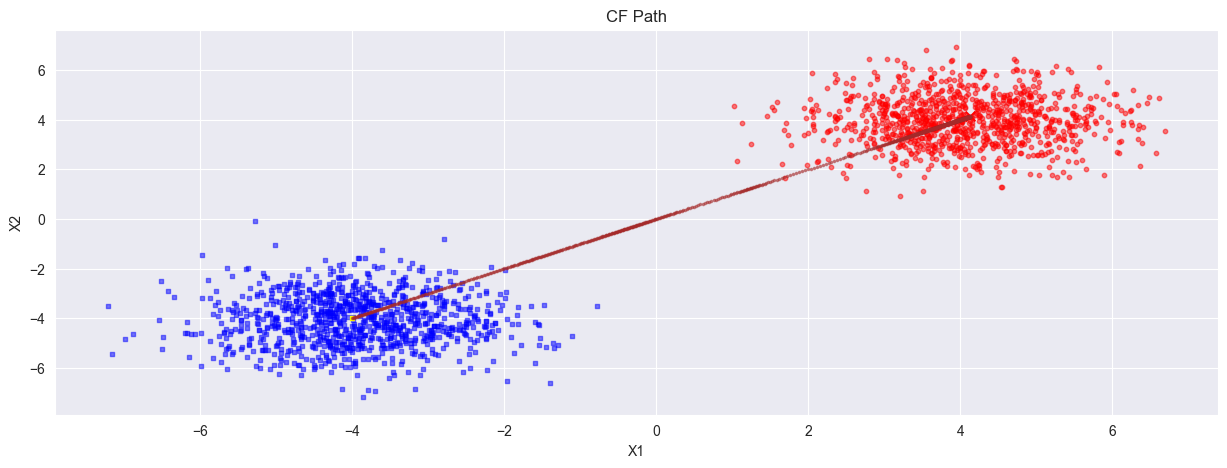

In [476]:
visualize_cf_and_steps(cf_plausable, cf_steps_plausable, points, y_pred_ensemble_points)

In [477]:
cf_plausable, cf_valid

(tensor([[4.1300, 4.1300]]), tensor([[3.3782, 3.3782]]))

In [478]:
epistemic_uncertainty_ensemble(ensemble_probs(cf_plausable)), epistemic_uncertainty_ensemble(ensemble_probs(cf_valid))

(tensor([0.0002]), tensor([0.0041]))

## Discrimitiveness

In [479]:
point_of_interest = torch.tensor(np.array([-4,-4]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([0]))
desired_class = 1

In [480]:
def discriminiative_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = aleatoric_uncertainty_ensemble(probs_ensemble)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        print(counter_factual,au, t)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_discriminiative, cf_steps_discriminiative = discriminiative_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

tensor([[-3.9900, -3.9900]], requires_grad=True) tensor([0.0027], grad_fn=<MeanBackward1>) 0
tensor([[-3.9800, -3.9800]], requires_grad=True) tensor([0.0028], grad_fn=<MeanBackward1>) 0
tensor([[-3.9700, -3.9700]], requires_grad=True) tensor([0.0029], grad_fn=<MeanBackward1>) 0
tensor([[-3.9599, -3.9599]], requires_grad=True) tensor([0.0030], grad_fn=<MeanBackward1>) 0
tensor([[-3.9499, -3.9499]], requires_grad=True) tensor([0.0031], grad_fn=<MeanBackward1>) 0
tensor([[-3.9398, -3.9398]], requires_grad=True) tensor([0.0032], grad_fn=<MeanBackward1>) 0
tensor([[-3.9296, -3.9296]], requires_grad=True) tensor([0.0033], grad_fn=<MeanBackward1>) 0
tensor([[-3.9195, -3.9195]], requires_grad=True) tensor([0.0034], grad_fn=<MeanBackward1>) 0
tensor([[-3.9092, -3.9092]], requires_grad=True) tensor([0.0035], grad_fn=<MeanBackward1>) 0
tensor([[-3.8990, -3.8990]], requires_grad=True) tensor([0.0037], grad_fn=<MeanBackward1>) 0
tensor([[-3.8886, -3.8886]], requires_grad=True) tensor([0.0038], grad

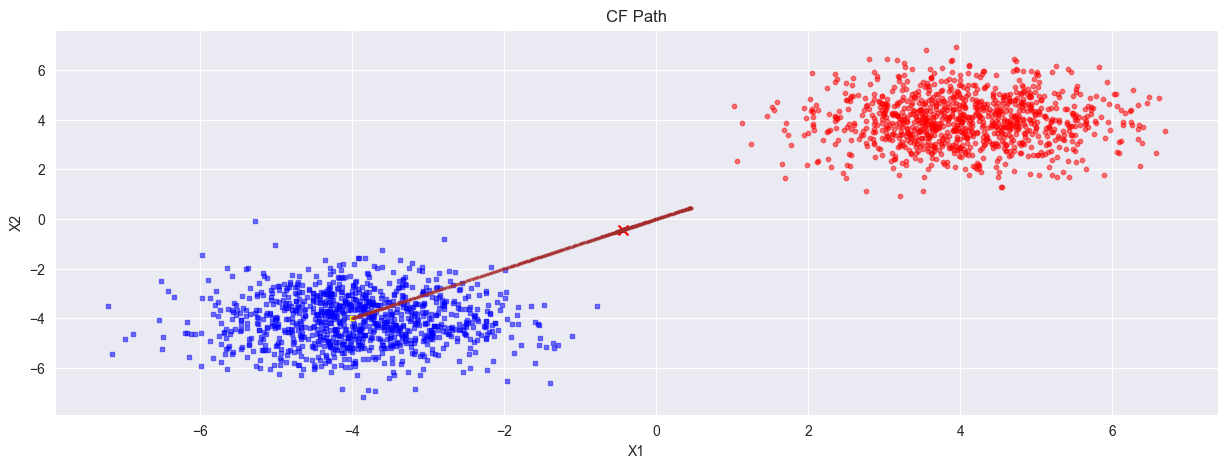

In [481]:
visualize_cf_and_steps(cf_discriminiative, cf_steps_discriminiative, points, y_pred_ensemble_points)


In [482]:
cf_discriminiative, cf_plausable, cf_valid

(tensor([[-0.4374, -0.4374]]),
 tensor([[4.1300, 4.1300]]),
 tensor([[3.3782, 3.3782]]))

In [483]:
aleatoric_uncertainty_ensemble(ensemble_probs(cf_plausable)), aleatoric_uncertainty_ensemble(ensemble_probs(cf_valid)), aleatoric_uncertainty_ensemble(ensemble_probs(cf_discriminiative))


(tensor([0.0010]), tensor([0.0130]), tensor([0.1379]))

## Stability

In [484]:
point_of_interest = torch.tensor(np.array([-4,-4]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([0]))
desired_class = 1

In [485]:
def sample_delta_ball(reference_point, delta, n_points):
    """
    :param point:
    :param delta:
    :param norm:
    :return:
    """
    delta_samples = []
    for _ in range(n_points):
        sample = np.random.randn(*reference_point.shape)
        sample /= np.linalg.norm(sample,ord=2,axis=-1, keepdims=True)
        delta_sample = sample  * delta
        delta_samples.append([delta_sample])
    samples = np.concatenate(delta_samples,axis=0)
    delta_samples = (reference_point + samples).astype(np.float32)
    return torch.tensor(delta_samples, requires_grad=True)

tensor(1.8309e-08, grad_fn=<MinBackward1>) tensor(0.3467, grad_fn=<MaxBackward1>)


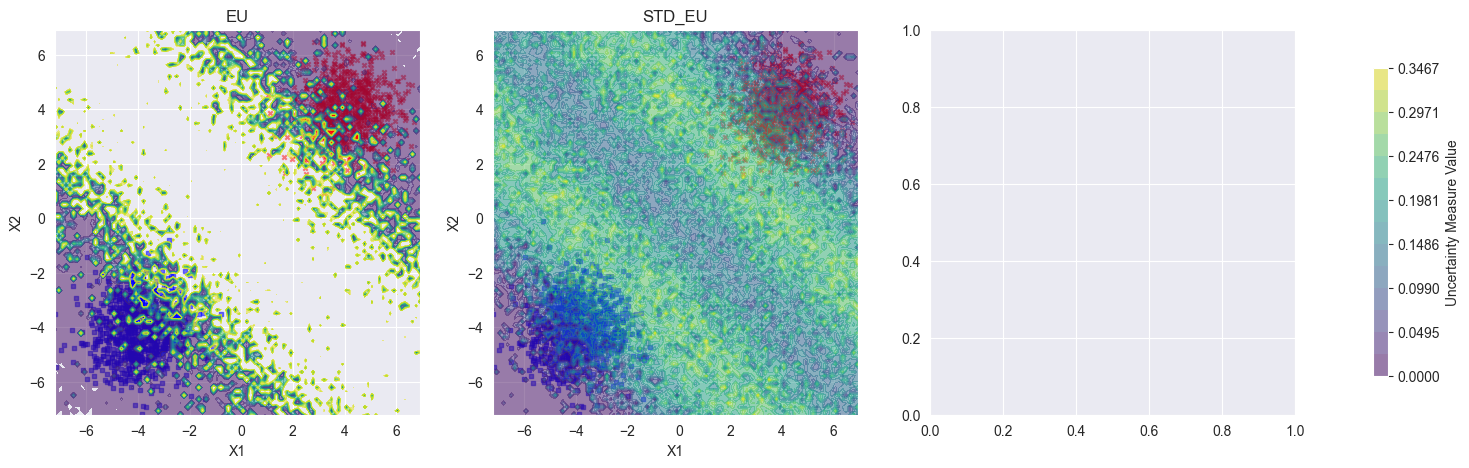

In [486]:
# visualize how std of eu looks like aroung the points
def visualize_au_eu_tu_points(points,y_labels):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T

    # Extract loss value
    tensor_points = torch.tensor(grid_points)
    probs_ensemble  = ensemble_probs(tensor_points)
    probs = probs_ensemble.mean(dim=0)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(probs_ensemble)


    # sample_ball
    delta_ball = sample_delta_ball(tensor_points.detach().numpy(),1,10)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball.view(-1,2))
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball).view(10,-1)


    std_eu_ball = torch.std(torch.cat((eu_delta_ball,epistemic_uncertainty.view(1,-1))),dim=0)

    # Shared value range
    all_vals = torch.concatenate([std_eu_ball], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

    plots = []
    for ax, data, title in zip(axes, [epistemic_uncertainty, std_eu_ball], ["EU","STD_EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_au_eu_tu_points(points,y_pred_ensemble_points)

In [487]:
def stable_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = aleatoric_uncertainty_ensemble(probs_ensemble)
        #eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points).view(-1,2)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball)
        #eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = torch.std(
            input=torch.cat(((-target_probs).add(t*au) , (-target_probs_delta_ball).add(t*au_delta_ball)))
        )
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
       # print(counter_factual,eu, t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_stable, cf_steps_stable = stable_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

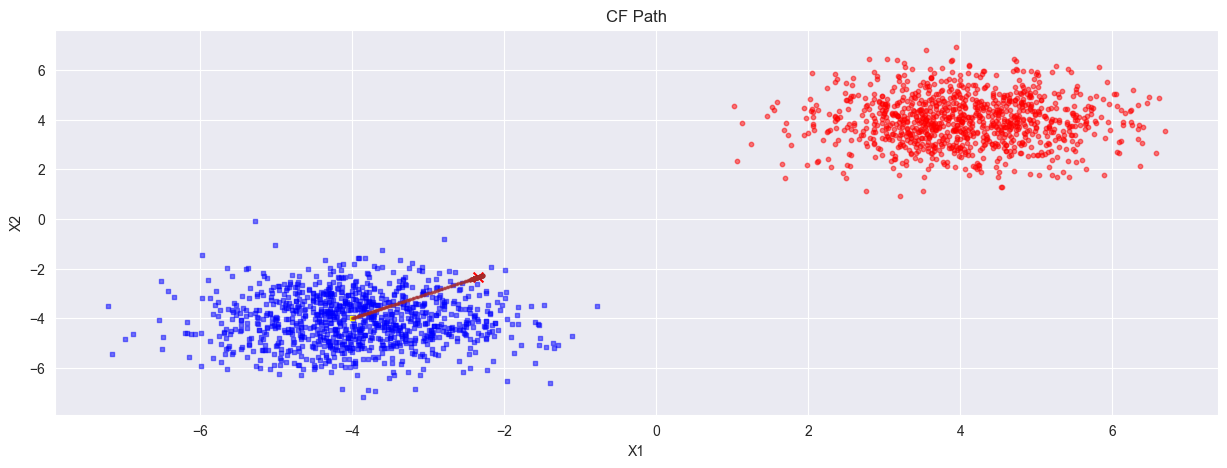

In [488]:
visualize_cf_and_steps(cf_stable,cf_steps_stable, points, y_pred_ensemble_points)

In [489]:
delta_point_of_interest = sample_delta_ball(point_of_interest.detach().numpy(), delta=1, n_points=10)
cf_points_stable = []
for point in delta_point_of_interest:
    cf_point, cf_steps_point = stable_procedure(point.view(-1,2), desired_validity=0.9, delta=1, n_points=10)
    #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
    cf_points_stable.append(cf_point)

# compare with validitiy procedure
cf_points_not_stable =[]
for point in delta_point_of_interest:
    cf_point, cf_steps_point = validity_procedure(point.view(-1,2), desired_validity=0.9)
    #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
    cf_points_not_stable.append(cf_point)


# compute the mean l2 distance for stable and not stable
l2_distances_stable = [
    torch.norm(p1 - p2, p=2).item()
    for p1 in cf_points_stable
    for p2 in cf_points_stable
    if (p1 != p2).all()
]
l2_distances_unstable = [
    torch.norm(p1 - p2, p=2).item()
    for p1 in cf_points_not_stable
    for p2 in cf_points_not_stable
    if (p1 != p2).all()
]

print("Mean L2-Distance of Stable Procedure: ", np.mean(l2_distances_stable), " +/- ",  np.std(l2_distances_stable))
print("Mean L2-Distance of Unstable Procedure: ", np.mean(l2_distances_unstable), " +/- ",  np.std(l2_distances_unstable))

Mean L2-Distance of Stable Procedure:  0.8886970130933656  +/-  0.6953624549136279
Mean L2-Distance of Unstable Procedure:  0.882169707533386  +/-  0.7011177794793699


## Robustness

In [490]:
point_of_interest = torch.tensor(np.array([-4,-4]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([0]))
desired_class = 1

In [491]:
def robust_procedure(point_to_explain, desired_validity=0.8, delta=0.2, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        eu = epistemic_uncertainty_ensemble(probs_ensemble)


        # sample_ball
        delta_ball = sample_delta_ball(counter_factual.detach().numpy(),delta,n_points).view(-1,2)
        probs_ensemble_delta_ball = ensemble_probs(delta_ball)
        probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
        eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball)


        target_probs = probs[0,desired_class]
        target_probs_delta_ball = probs_delta_ball[:,desired_class]

        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE

        std_eu_ball = torch.std(
            eu_delta_ball
        )**2
        mean_eu_ball = torch.mean(
            eu_delta_ball
        )
        # Calculate the loss
        loss = (-target_probs + (t*std_eu_ball))

        # Backpropagate
        loss.backward()
        optimizer.step()
        print(counter_factual,eu,std_eu_ball,mean_eu_ball, t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_robust, cf_steps_robust = robust_procedure(point_of_interest,delta=0.5)

tensor([[-3.9900, -3.9900]], requires_grad=True) tensor([0.0005], grad_fn=<ClampBackward1>) tensor(0.0066, grad_fn=<PowBackward0>) tensor(0.0424, grad_fn=<MeanBackward0>) 0 0
tensor([[-3.9800, -3.9800]], requires_grad=True) tensor([0.0006], grad_fn=<ClampBackward1>) tensor(0.0006, grad_fn=<PowBackward0>) tensor(0.0139, grad_fn=<MeanBackward0>) 0 1
tensor([[-3.9700, -3.9700]], requires_grad=True) tensor([0.0006], grad_fn=<ClampBackward1>) tensor(0.0021, grad_fn=<PowBackward0>) tensor(0.0261, grad_fn=<MeanBackward0>) 0 2
tensor([[-3.9599, -3.9599]], requires_grad=True) tensor([0.0006], grad_fn=<ClampBackward1>) tensor(0.0007, grad_fn=<PowBackward0>) tensor(0.0121, grad_fn=<MeanBackward0>) 0 3
tensor([[-3.9499, -3.9499]], requires_grad=True) tensor([0.0006], grad_fn=<ClampBackward1>) tensor(0.0112, grad_fn=<PowBackward0>) tensor(0.0578, grad_fn=<MeanBackward0>) 0 4
tensor([[-3.9398, -3.9398]], requires_grad=True) tensor([0.0007], grad_fn=<ClampBackward1>) tensor(0.0068, grad_fn=<PowBackwa

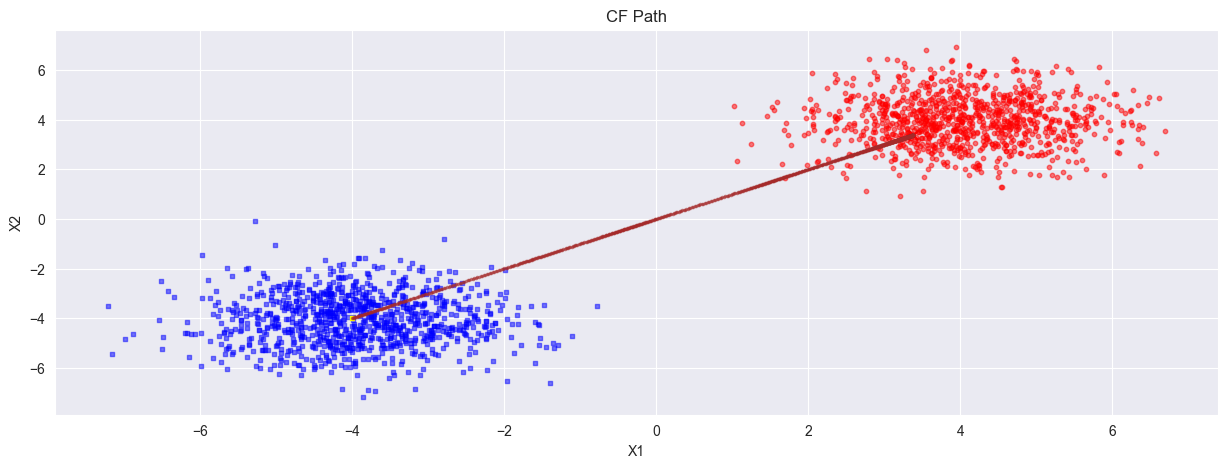

In [492]:
visualize_cf_and_steps(cf_robust,cf_steps_robust, points, y_pred_ensemble_points)

In [493]:
cf_robust, cf_plausable

(tensor([[3.3782, 3.3782]]), tensor([[4.1300, 4.1300]]))

In [494]:
epistemic_uncertainty_ensemble(ensemble_probs(cf_robust)), epistemic_uncertainty_ensemble(ensemble_probs(cf_plausable))

(tensor([0.0041]), tensor([0.0002]))

In [495]:
delta_cf_robust = sample_delta_ball(cf_robust.detach().numpy(), delta=1, n_points=10)
epistemic_cf_robust = []
for point in delta_cf_robust:
    #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
    epistemic_cf_robust.append(
        epistemic_uncertainty_ensemble(ensemble_probs(point.view(-1,2))).detach().numpy()
    )

delta_cf_plausable = sample_delta_ball(cf_plausable.detach().numpy(), delta=1, n_points=10)
epistemic_cf_plausable = []
for point in delta_cf_plausable:
    #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
    epistemic_cf_plausable.append(
        epistemic_uncertainty_ensemble(ensemble_probs(point.view(-1,2))).detach().numpy()
    )

print("Std Epistemic Uncertainty of Robust Procedure: ",np.mean(epistemic_cf_robust) , " +/- " ,  np.std(epistemic_cf_robust))
print("Std Epistemic Uncertainty of Plausable Procedure: ", np.mean(epistemic_cf_plausable) , " +/- " , np.std(epistemic_cf_plausable))

Std Epistemic Uncertainty of Robust Procedure:  0.016801223  +/-  0.02120337
Std Epistemic Uncertainty of Plausable Procedure:  0.0011302559  +/-  0.001479157


## Connectednss

In [496]:
def sample_line(x1, x2, num_samples=10):
    """
    Returns `num_samples` points along the line from `x1` to `x2`.
    Supports gradients with respect to x1 and x2.

    Args:
        x1 (torch.Tensor): Starting point (shape: [D])
        x2 (torch.Tensor): Ending point (shape: [D])
        num_samples (int): Number of points to sample along the line

    Returns:
        torch.Tensor: Points along the line (shape: [num_samples, D])
    """
    # Ensure inputs are tensors with gradient tracking
    x1 = x1.requires_grad_()
    x2 = x2.requires_grad_()

    # Create interpolation coefficients t in [0, 1]
    t = torch.linspace(0, 1, num_samples, device=x1.device).unsqueeze(1)  # shape: [num_samples, 1]

    # Linear interpolation
    points = (1 - t) * x1 + t * x2  # shape: [num_samples, D]
    return points

In [497]:
def connectedness_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        au = epistemic_uncertainty_ensemble(probs_ensemble)


        # Choose as reference point the point with highest probability for this class in the dataset
        probs_reference = ensemble_probs(torch.tensor(points)).mean(dim=0)[:,desired_class]
        idx_reference = np.argmax(probs_reference)
        reference_point = torch.tensor(points[idx_reference])



        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point,num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        au_line = epistemic_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = -target_probs + t*torch.std(
            input=torch.cat((au_line , au))
        )
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_connected, cf_steps_connected = connectedness_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

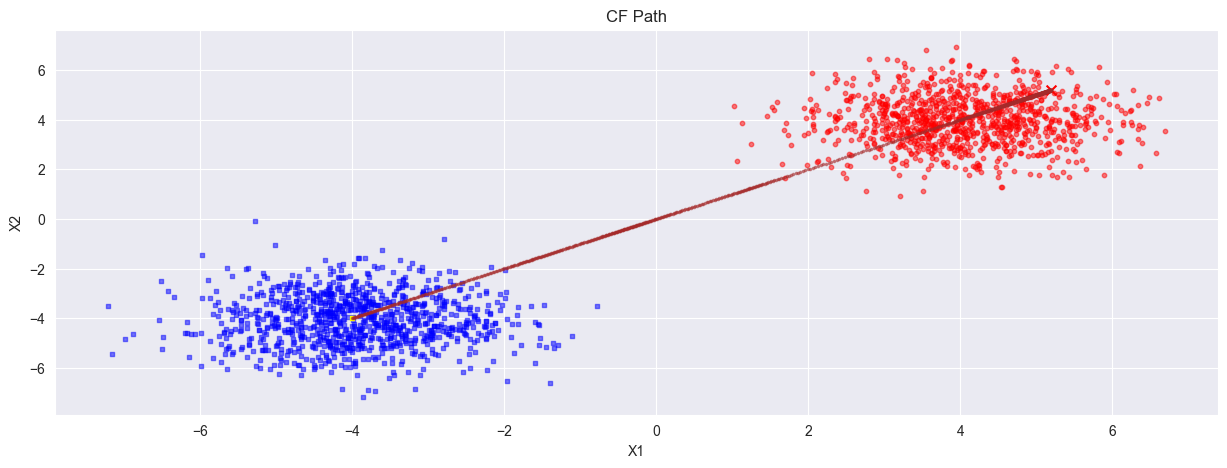

In [498]:
visualize_cf_and_steps(cf_connected,cf_steps_connected, points, y_pred_ensemble_points)

In [499]:
def connectedness_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)
        tu = total_uncertainty_ensemble(probs_ensemble)

        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = -target_probs + t*tu
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_connected, cf_steps_connected = connectedness_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

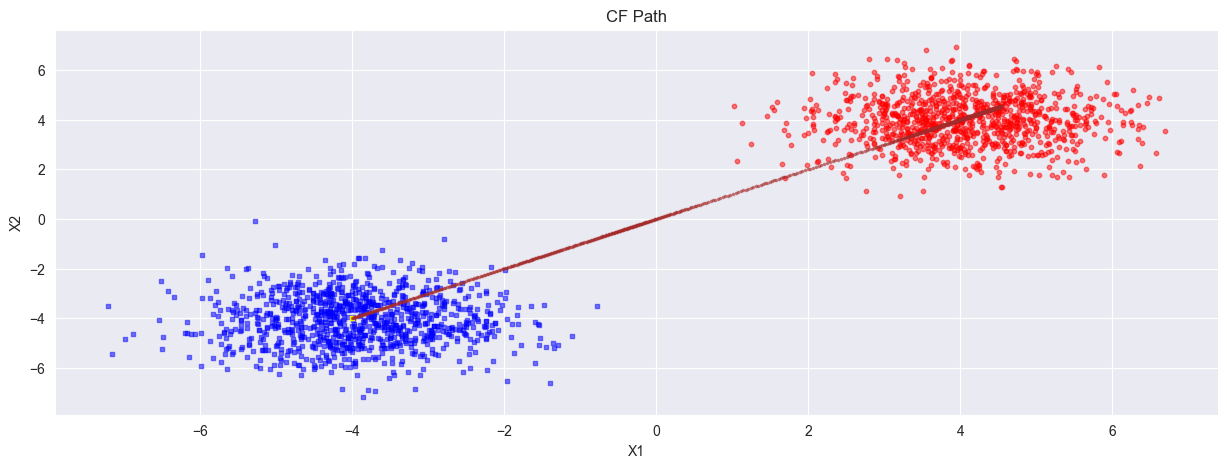

In [500]:
visualize_cf_and_steps(cf_connected,cf_steps_connected, points, y_pred_ensemble_points)

## Similiarity

In [504]:
def similiarity_procedure(point_to_explain, desired_validity=0.8, delta=1, n_points=10):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    probs_ensemble  = ensemble_probs(counter_factual)
    probs = probs_ensemble.mean(dim=0)

    target_probs = probs[0,desired_class]
    # Optimization Iteration

    t = 0
    T = 0
    while T < MAX_STEPS:
        optimizer.zero_grad()

        # Extract loss value
        probs_ensemble  = ensemble_probs(counter_factual)
        probs = probs_ensemble.mean(dim=0)



        reference_point = point_to_explain.clone().detach().requires_grad_(True)



        # sample_ball
        sampled_line_points = sample_line(counter_factual, reference_point,num_samples=n_points)
        probs_ensemble_line_points = ensemble_probs(sampled_line_points)
        probs_delta_ball = probs_ensemble_line_points.mean(dim=0)
        au_line = aleatoric_uncertainty_ensemble(probs_ensemble_line_points)


        target_probs = probs[0,desired_class]
        if target_probs > 0.5:
            t += UNCERTAINTY_STEP_INCREASE
        # Calculate the loss
        loss = -target_probs - torch.mean(
            au_line
        )
        #loss = (-target_probs).add(t*au)

        # Backpropagate
        loss.backward()
        optimizer.step()
        #print(counter_factual, au , t, T)

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
        T += 1
    return counter_factual.detach(), counter_factual_steps

cf_similiar, cf_steps_similiar = similiarity_procedure(point_of_interest,desired_validity=DESIRED_VALIDITY)

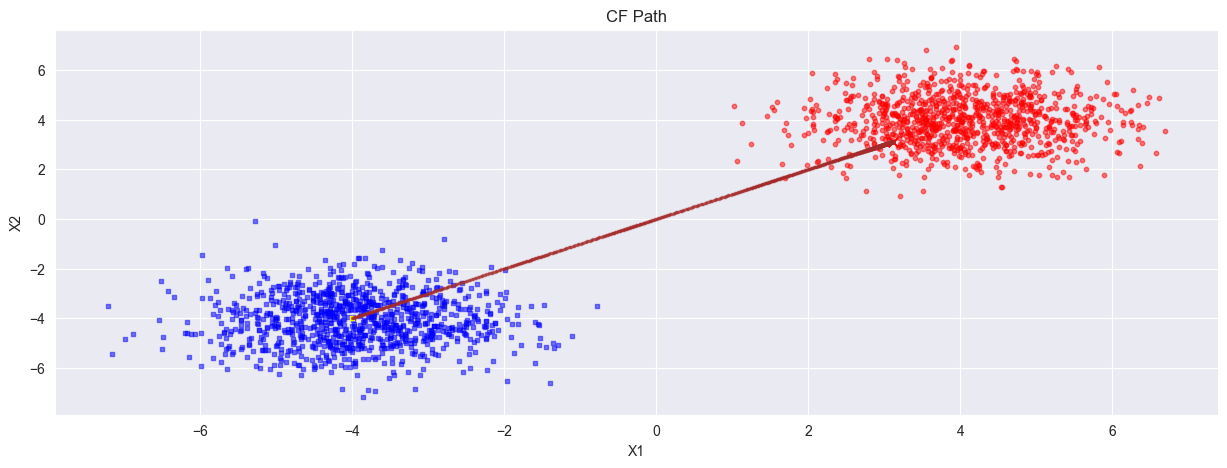

In [505]:
visualize_cf_and_steps(cf_similiar, cf_steps_similiar, points, y_pred_ensemble_points)

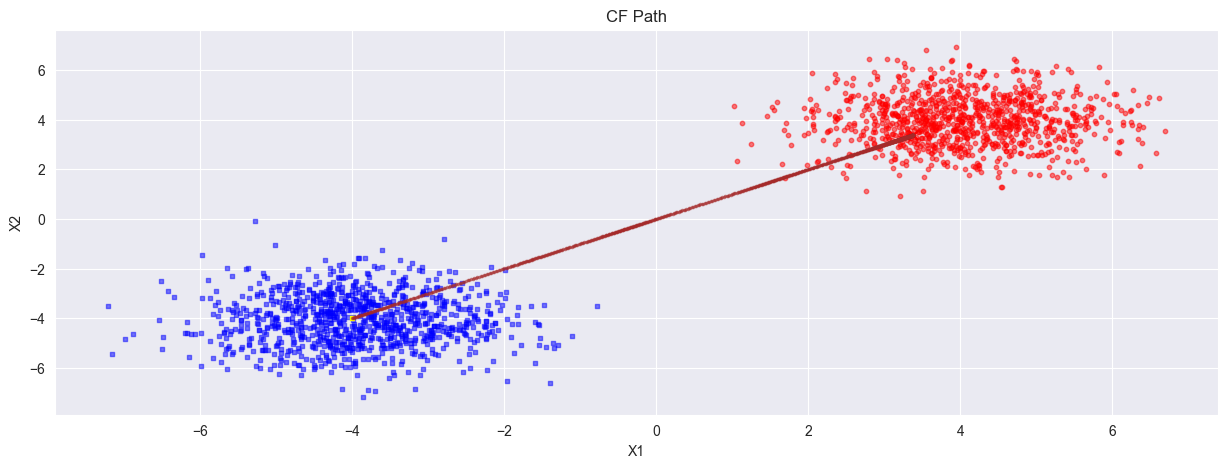

In [506]:
visualize_cf_and_steps(cf_valid,cf_steps_valid, points, y_pred_ensemble_points)

In [507]:
#l2 distance of similiar and valid
torch.linalg.norm(cf_similiar - point_of_interest, ord=2)

tensor(10.0661, grad_fn=<AmaxBackward0>)

In [508]:
torch.linalg.norm(cf_valid - point_of_interest, ord=2)

tensor(10.4344, grad_fn=<AmaxBackward0>)